In [1]:
import numpy as np
import scipy as sp
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal,norm
from collections import defaultdict
import warnings
import sklearn.exceptions
from scipy.special import erfinv
from sklearn.metrics import precision_score, recall_score, f1_score
from tqdm.notebook import tqdm
import os

import matplotlib.pyplot as plt

from _util import *

warnings.filterwarnings("ignore", category=sklearn.exceptions.ConvergenceWarning)

plt.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath} \usepackage{amssymb}'
plt.rc('text', usetex=True)
plt.rc('font', family='serif')

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)

np.set_printoptions(edgeitems=30, linewidth=100000, formatter=dict(float=lambda x: "%.3g" % x))


make_plot = lambda n,m,s=[1,1],sharex=False, sharey=False: plt.subplots(n,m,figsize=(m*3*s[0],n*2.5*s[1]),squeeze=False,layout='tight',sharex=sharex, sharey=sharey)
line_style = [
    '-',                  # Solid line.
    '--',                 # Dashed line.
    '-.',                 # Dashdot line.
    ':',                  # Dotted line.
    (0, (3, 5, 1, 5)),    # Custom dash pattern: 3 on, 5 off, 1 on, 5 off.
    (0, (1, 10))         # Custom dash pattern: 1 on, 10 off.
]

def rank_approx(A, k,sort_type="big_small"):
    # Eigenvalue Decomposition (since A is symmetric, we can use eigh)
    eigenvalues, eigenvectors = np.linalg.eigh(A)
    
    # Sort eigenvalues and corresponding eigenvectors in descending order
    if sort_type == "big_small":
        idx = np.argsort(eigenvalues)[::-1]
    elif sort_type == "small_big":
        idx = np.argsort(eigenvalues)
    
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]
    
    # Select the top-k eigenvalues and eigenvectors
    top_eigenvalues = np.diag(eigenvalues[:k])
    top_eigenvectors = eigenvectors[:, :k]
    
    # Reconstruct the rank-k approximation
    A_k = top_eigenvectors @ top_eigenvalues @ top_eigenvectors.T
    
    return A_k


def print_eig(matrix):

    # Validate symmetry
    if not np.allclose(matrix, matrix.T):
      raise ValueError("Error: The matrix is not symmetric.")
    
    # Compute eigenvalues and eigenvectors using an algorithm optimized for symmetric matrices
    eigenvalues, eigenvectors = np.linalg.eigh(matrix)
    
    # Sort eigenvalues and corresponding eigenvectors in ascending order.
    sorted_indices = np.argsort(eigenvalues)
    sorted_eigenvalues = eigenvalues[sorted_indices]
    sorted_eigenvectors = eigenvectors[:, sorted_indices]
    
    # Create a DataFrame where each column header is a sorted eigenvalue,
    # and the column entries are the corresponding eigenvector components.
    df = pd.DataFrame(sorted_eigenvectors, columns=[f"{val:.4f}" for val in sorted_eigenvalues])
    
    # Append the final row labeled "sum" with the sum of each column (eigenvector)
    df.loc['sum'] = df.sum(axis=0)
    
    # Configure Pandas display options to avoid wrapping the DataFrame after a set number of columns.
    pd.set_option('display.max_columns', None)
    pd.set_option('display.expand_frame_repr', False)
    
    # Print the table to the console.
    print("Eigenvalue Table:")
    print(df)

def compute_metrics(result, C_true, iC_true, Y):

    if result is None or np.isnan(np.sum(result.iC)):
        result_metrics = {
            'err_C': np.nan,
            'err_iC': np.nan,
            'err_S': np.nan,
            'nnz': np.nan,
            'nll': np.nan,
            'sphr': np.nan,
            'precision': np.nan,
            'recall': np.nan,
            'f1': np.nan,
            'kl': np.nan,
            'aic':np.nan,
            'runtime': np.nan
        }
        return SimpleNamespace(**result_metrics)

    p, n = Y.shape
    S   = np.cov(Y, bias=True)
    C   = result.C + np.eye(p) * 1e-6
    iC  = result.iC + np.eye(p) * 1e-6

    # Use X if available, otherwise default to iC
    X = result.X if hasattr(result, "X") else iC

    # Compute error metrics on covariance/precision matrices
    err_C  = np.linalg.norm(C  - C_true, ord="fro")**2 / np.linalg.norm(C_true, ord="fro")**2
    err_iC = np.linalg.norm(iC - iC_true, ord="fro")**2 / np.linalg.norm(iC_true, ord="fro")**2
    err_S  = np.linalg.norm(C  - S, ord="fro")**2
    nnz    = np.count_nonzero(X) / p
    
    (sign, logdet) = np.linalg.slogdet(iC)
    nll = - (sign * logdet) + np.trace(iC @ S)

    sphr   = p * np.trace(X @ X) / np.trace(X)**2 - 1 
    aic    =  nll + ( nnz  - p )/2 + p

    # Compute KL divergence loss for two zero-mean Gaussians.
    # KL = 0.5 * (trace(iC @ C_true) - p + log(det(C) / det(C_true)))
    kl = 0.5 * (np.trace(iC @ C_true) - p + np.log(np.linalg.det(C) / np.linalg.det(C_true)))
    
    # Compute F1 score for structure recovery of the precision matrix.
    # Threshold the absolute values to define nonzero connections.
    tol = 1e-5
    est_support = np.abs(iC) > tol
    true_support = np.abs(iC_true) > tol

    # Exclude the diagonal entries from evaluation.
    np.fill_diagonal(est_support, False)
    np.fill_diagonal(true_support, False)

    # Flatten binary matrices into 1D arrays.
    y_true = true_support.flatten()
    y_pred = est_support.flatten()

    # Compute the metrics using scikit-learn.
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    # Compile all computed metrics into a structured object.
    result_metrics = {
        'err_C': err_C,
        'err_iC': err_iC,
        'err_S': err_S,
        'nnz': nnz,
        'nll': nll,
        'sphr': sphr,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'kl': kl,
        'aic':aic,
        'runtime': result.runtime
    }
    return SimpleNamespace(**result_metrics)

def metrics_list(results):
    if len(results)<1:
        return []
    if isinstance(results, list) and results:
        # Dynamically retrieve keys from the first result (e.g., 'err_C', 'err_iC', etc.)
        keys = vars(results[0]).keys()
        aggregated = {key: [getattr(r, key) for r in results] for key in keys}
        return SimpleNamespace(**aggregated)
    else:
        return results

During startup - Warning messages:
1: Setting LC_COLLATE failed, using "C" 
2: Setting LC_TIME failed, using "C" 
3: Setting LC_MESSAGES failed, using "C" 
4: Setting LC_MONETARY failed, using "C" 


# fig1: Tunning Paramter

num nnzpr = 18.625
num nnzpr = 31.78125
num nnzpr = 41.546875
Figure size (width x height in pixels): [7.2 2.5] 0.34722222222222227


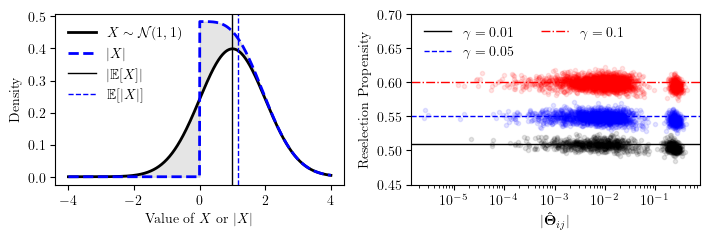

In [ ]:
def cov_analysis(p=128, N=1000,gamma=1/100, data_method='cluster'):

    n = int(p*20)
    k = n/2
    # Generate true covariance
    iC_true, C_true = make_cov(p, data_type=data_method, seed=1)
    Y = make_samples(cov=C_true, n=n,seed=1)
    Y,_,_ = normalize_data(Y)

    res_aquic = compute_aquic(Y,k=k,gamma=gamma) 

    iC = res_aquic.iC
    C  = res_aquic.C

    print("num nnzpr =",np.count_nonzero(iC)/p)

    # Calculate mean and variance of S_k
    S = np.cov(Y, bias=True)
    V = np.outer(np.diag(S), np.diag(S)) + S ** 2

    # Compute  L
    L = erfinv(1 - 2 * gamma) / np.sqrt(2 * k) * np.sqrt(V)
    np.fill_diagonal(L, 0)
    P = np.zeros(shape=(p,p))

    for i in range(N):
        inx_k = np.random.choice(int(n), size=int(k),replace=True)
        Y_k = Y[:, inx_k]
        S_k = np.cov(Y_k, bias=True)
        G_k  = S_k - C
        G_k = G_k - np.diag(np.diag(G_k))
        P = P + (np.abs(G_k) >= L) * 1.0

    P = P / N

    pr_nnz =[]
    pr_z   =[]
    iC_nnz =[]
    iC_z   =[]

    for i in range(p):
        for j in range(i-1):
            if np.abs(iC[i,j]) > 0.0:
                #print(rf"iC[{i},{j}]={iC[i,j]} with prob {P[i,j]}")
                pr_nnz.append(P[i,j])
                iC_nnz.append(iC[i,j])
            else:
                pr_z.append(P[i,j])
                iC_z.append(iC[i,j])

    return pr_nnz,pr_z,iC_nnz,iC_z

fig, axs = make_plot(1,2,s=[1.2,1],sharex=False, sharey=False)

inx = 0
#########################
#########################
mu = 1
sigma = 1
x = np.linspace(-4, 4, 1000)

pdf_normal = sp.stats.norm.pdf(x, mu, sigma)
c = abs(mu / sigma)

pdf_folded  = sp.stats.foldnorm.pdf(x, c, scale=sigma)
mean_folded = sp.stats.foldnorm.mean(c, scale=sigma)

# Normal distribution
axs[0,inx].plot(x, pdf_normal, label=r"$X\sim\mathcal{N}(1,1)$", color="black",linestyle="-",linewidth=2)
axs[0,inx].fill_between(x[x < 0], pdf_normal[x < 0], color='black', alpha=0.1)
axs[0,inx].plot(x, pdf_folded, label=r"$|X|$", color="blue",linestyle="--",linewidth=2)

# Highlighting how negative side maps to positive side in folded normal
axs[0,inx].fill_between(x[x>0],pdf_folded[x > 0], pdf_normal[x > 0], color='black', alpha=0.1)

# Mean lines
axs[0,inx].axvline(mu, color='black', label=r"$|\mathbb{E}[X]|$",linestyle="-",linewidth=1)
axs[0,inx].axvline(mean_folded, color='blue', label=r"$\mathbb{E}[|X|]$",linestyle="--",linewidth=1)

axs[0, inx].set_xlabel(r'Value of $X$ or $|X|$')
axs[0, inx].set_ylabel(r'Density')
axs[0, inx].legend(loc='upper left',frameon=False,fontsize=10)

inx = inx + 1
#########################
#########################
ax = axs[0, inx]
data_method = "cluster"
# … after plotting your markers …

for color, linestyle, gamma in [
    ('black', '-' , 0.01),
    ('blue' , '--', 0.05),
    ('red',  '-.' , 0.10)
]:
    # 1) re‑run your semilogx for clarity (or omit if already plotted)
    pr_nnz, pr_z, iC_nnz, iC_z = cov_analysis(
        p=128, gamma=gamma, data_method=data_method, N=10000
    )
    ax.semilogx(
        np.abs(iC_nnz),
        pr_nnz,
        linestyle='None',
        marker='.',
        color=color,
        alpha=0.1,
        label="_"
    )
    ax.axhline(y=(0.5 + gamma), color=color, linewidth=1, linestyle=linestyle, alpha=1, label=rf'$\gamma={gamma}$')

axs[0, inx].set_ylabel(r'Reselection Probability')
axs[0, inx].set_xlabel(r'$|\mathbf{\hat{\Theta}}_{ij}|$')

axs[0, inx].set_ylim([0.45,0.7])
axs[0, inx].legend(loc='upper left',frameon=False,fontsize=10,ncol=2)

fig.savefig("fig_1.png", dpi=300)

fig_size_pixels = fig.get_size_inches()
print("Figure size (width x height in pixels):", fig_size_pixels, fig_size_pixels[1] / fig_size_pixels[0])

# fig2: Sampling Distribution NNZ

In [ ]:
def single_run1(p,n,c,data_type):

    iC_true, C_true = make_cov(p, data_type=data_type, seed=0, dense=True)
    Y = make_samples(cov=C_true, n=int(n), seed=2)
    Y,_,_ = normalize_data(Y)
    S = np.cov(Y,bias=True)

    k = n / 2 
    gamma = 0.5 *  (1.0 - sp.special.erf(2.0 * sp.special.erfinv(1.0 - c / p))) 

    diagS = np.diagonal(S)                         
    V = S**2 + np.outer(diagS, diagS)              
    L = 0.5 * sp.special.erfinv(1.0 - 2.0 * gamma) * np.sqrt(2.0*V/k)
    np.fill_diagonal(L, 1e-12)

    res_aquic = compute_aquic(Y,c=c,k=k)

    C  = res_aquic.W
    iC = res_aquic.X

    nnzpr_min = c
    nnzpr_max = p*(0.5 + gamma)
    nnzpr_actual = (np.count_nonzero(iC))/p
    nnzpr_true  = (np.count_nonzero(iC_true))/p

    N = 1000
    nnzpr_set = np.zeros(N)

    for i in range(N):
        inx_k = np.random.choice(int(n), size=int(k))
        Y_k = Y[:, inx_k]
        S_k = np.cov(Y_k, bias=True)
        G_k  = S_k - C
        P = (np.abs(G_k) >= L) * 1.0
        nnzpr = (np.count_nonzero(P))/p
        nnzpr_set[i] = nnzpr
    
    return nnzpr_set,nnzpr_min,nnzpr_max,nnzpr_actual,nnzpr_true

def single_run2(p_line, data_type):

    nnz1 = np.zeros(len(p_line))
    nnz2 = np.zeros(len(p_line))
    nnz3 = np.zeros(len(p_line))
    nnz_true = np.zeros(len(p_line))
    for inx,p in enumerate(p_line):
        print(p)

        n = p/2
        iC_true, C_true = make_cov(p, data_type=data_type, seed=0)
        Y = make_samples(cov=C_true, n=int(n), seed=1)
        nnz_true[inx] = np.count_nonzero(iC_true) / p

        res_aquic1 = compute_aquic(Y,gamma=1/100)
        met_aquic1 = compute_metrics(res_aquic1, C_true, iC_true, Y)

        res_aquic2 = compute_aquic(Y,c=30)
        met_aquic2 = compute_metrics(res_aquic2, C_true, iC_true, Y)

        res_aquic3 = compute_aquic(Y,c=5)
        met_aquic3 = compute_metrics(res_aquic3, C_true, iC_true, Y)

        nnz1[inx]=met_aquic1.nnz
        nnz2[inx]=met_aquic2.nnz
        nnz3[inx]=met_aquic3.nnz

    return nnz1,nnz2,nnz3,nnz_true

data_type = "cluster"

fig, axs = make_plot(1,2,s=[1.2,1],sharex=False, sharey=False)

########################################
inx = 0
########################################
p = 128
n = p/2
c = 30
nnzpr_set,nnzpr_min,nnzpr_max,nnzpr_actual,nnzpr_true = single_run1(p,n,c,data_type)
axs[0,inx].hist(nnzpr_set, bins=30, density=False, color="black", alpha=.2)
axs[0,inx].axvline(x=np.mean(nnzpr_set), color="black",    linestyle="-",  linewidth=2, label=r"$\bar{z}$")
axs[0,inx].axvline(x=nnzpr_min,          color="blue",     linestyle="--", linewidth=2, label=r"$\bar{z}_{\text{min}}$")
axs[0,inx].axvline(x=nnzpr_actual,       color="green",    linestyle=":",  linewidth=2, label=r"$s$")
axs[0,inx].minorticks_on()
axs[0,inx].set_xlim([10,70])
axs[0,inx].set_ylabel(f"Frequency")
axs[0,inx].set_xlabel(r"Sampling Nonzeros Per Row ($z$)")
axs[0, inx].legend(loc='upper right', frameon=False, fontsize=10, ncol=1)

########################################
inx = inx + 1
########################################
p_line = [32,64,128,256,512,1024]
nnz1,nnz2,nnz3,nnz_true = single_run2(p_line, data_type)
axs[0,inx].loglog(p_line,nnz1,     color="black",   linestyle="-",  linewidth=2 , label=f"$\gamma=1/100$")
axs[0,inx].loglog(p_line,nnz2,     color="green",   linestyle=":",  linewidth=2 , label=f"$c=30$")
axs[0,inx].loglog(p_line,nnz3,     color="blue",    linestyle="-.", linewidth=2 , label=f"$c=5$")
axs[0,inx].loglog(p_line,nnz_true, color="magenta", linestyle="--", linewidth=1 , label=f"True")

base = nnz1[0]
y = np.array(p_line)
y = (base / y[0]) * y + 2

axs[0,inx].loglog(p_line,y,color="red",linestyle="-", linewidth=1 ,label=f"$\propto p$", alpha=.6)

axs[0,inx].set_xscale('log', base=2)
axs[0,inx].set_xticks(p_line)
axs[0,inx].set_xticklabels([str(int(val)) for val in p_line])
axs[0,inx].set_ylim([1,1e3])

axs[0,inx].set_ylabel(r"Nonzeros Per Row ($s$)")
axs[0,inx].set_xlabel(r"Number of Features ($p$)")
axs[0,inx].legend(loc="upper left", frameon=False, fontsize=10, ncol=2)

fig.savefig("fig_2.png", dpi=300)

# fig3: Err 1 - Fixed $p$, change in $n$

In [ ]:
def single_run(inx, n_ratio, C_true, iC_true):
    
    p = C_true.shape[0]
    n = int( np.ceil(n_ratio * p))
    Y = make_samples(cov=C_true, n=int(n), seed=inx)
    
    res_glasso = None
    res_tiger  = None
    res_clime  = None
    res_aquic1 = None
    res_aquic2 = None

    # GLASSO
    res_glasso = compute_glasso(Y)
    met_glasso = compute_metrics(res_glasso, C_true, iC_true, Y)

    #TIGER 
    res_tiger = compute_tiger(Y)
    met_tiger = compute_metrics(res_tiger, C_true, iC_true, Y)

    # CLIME  
    res_clime = compute_clime(Y)
    met_clime = compute_metrics(res_clime, C_true, iC_true, Y)

    # AQUIC 
    res_aquic1 = compute_aquic(Y,c=30,k=n/2)
    met_aquic1 = compute_metrics(res_aquic1, C_true, iC_true, Y)

    # AQUIC 
    res_aquic2 = compute_aquic(Y,c=5,k=n/2)
    met_aquic2 = compute_metrics(res_aquic2, C_true, iC_true, Y)

    print(
        f"- nnzpr {np.count_nonzero(iC_true)/p:.1f} | "
        f"glasso {met_glasso.runtime:.3f}s ({met_glasso.nnz:.1f}, f1={met_glasso.f1:.3f}) | "
        f"tiger {met_tiger.runtime:.3f}s ({met_tiger.nnz:.1f}, f1={met_tiger.f1:.3f}) | "
        f"clime {met_clime.runtime:.3f}s ({met_clime.nnz:.1f}, f1={met_clime.f1:.3f}) | "
        f"aquic1 {met_aquic1.runtime:.3f}s ({met_aquic1.nnz:.1f}, f1={met_aquic1.f1:.3f}) | "
        f"aquic2 {met_aquic2.runtime:.3f}s ({met_aquic2.nnz:.1f}, f1={met_aquic2.f1:.3f}) | "        
    )

    return {
        'glasso':  met_glasso,
        'tiger':   met_tiger,
        'clime':   met_clime,
        'aquic1':  met_aquic1,
        'aquic2':  met_aquic2,
    }


def convert_to_dataframes(raw_data):
    out = {}
    # Use the methods in the first task result as reference.
    for method in raw_data[0]:
        # Get the metric names from the first non-None result.
        first_valid = next((ns for ns in raw_data[0][method] if ns is not None), None)
        if first_valid is None:
            continue
        metric_names = list(first_valid.__dict__.keys())
        method_metrics = {}
        # For each metric, build one column per task.
        for metric in metric_names:
            # Each column corresponds to one task (one n_ratio value)
            cols = [
                np.array([ns.__dict__[metric] if ns is not None else np.nan for ns in task[method]])
                for task in raw_data
            ]
            # Stack columns horizontally so that rows are iterations.
            matrix = np.column_stack(cols)
            method_metrics[metric] = pd.DataFrame(matrix, columns=list(range(len(raw_data))))
        out[method] = SimpleNamespace(**method_metrics)
    return out

p  = 128
N  = 10

os.environ["PYTHONWARNINGS"] = "ignore"  # Applies to all subprocesses

data_type_list = ["cluster", "band", "hub"]

dataframes = {}
for data_type in data_type_list:
    print("Processing data type:", data_type)
    
    # Generate covariance matrix and samples.
    iC_true, C_true = make_cov(p, data_type=data_type, seed=0)

    # Define the n_ratio values.
    n_ratio_set = np.logspace(np.log2(1./8.), np.log2(2.0), num=10,base=2)
    
    # For each n_ratio value, run 100 iterations in parallel.
    raw_data = []  # Will be a list (length = number of n_ratio values).
    for n_ratio in n_ratio_set:
        print(f"Running n_ratio={n_ratio} iterations")
        
        task_input_list = [(inx, n_ratio, C_true, iC_true) for inx in range(N)]
        single_results = []
        for args in tqdm(task_input_list, total=N, desc=f"n_ratio={n_ratio} iterations"):
            result = single_run(*args)
            single_results.append(result)
        
        # For each method, we now want a list of 100 results.
        task_result = {method: [res[method] for res in single_results]
                       for method in single_results[0]}
        raw_data.append(task_result)
    
    # Convert the raw_data (list per n_ratio value) into matrices per metric.
    dataframes[data_type] = convert_to_dataframes(raw_data)

file_name = 'data_err1.pkl'
pd.to_pickle([n_ratio_set,dataframes], file_name)    

In [ ]:
file_name = "data_err1"
[x_line, dataframe] = pd.read_pickle(file_name + ".pkl") 

fig, axs = make_plot(7, 3, s=[1, .7], sharex=True, sharey='row')

std_band = 1

i = 0
# KL Divergence
for inx, data_type in enumerate(["cluster", "band", "hub"]):
    
    # aquic1
    m = dataframe[data_type]['aquic1'].kl.mean(0)
    v = dataframe[data_type]['aquic1'].kl.std(0) * std_band
    axs[i, inx].loglog(x_line, m, color="black", linestyle=line_style[0], label=r"$\texttt{aquic}(c=30)$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="black")
    
    #aquic2
    m = dataframe[data_type]['aquic2'].kl.mean(0)
    v = dataframe[data_type]['aquic2'].kl.std(0) * std_band
    axs[i, inx].loglog(x_line, m, color="orange", linestyle=line_style[1], label=r"$\texttt{aquic}(c=5)$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="orange")
    
    # glasso
    m = dataframe[data_type]['glasso'].kl.mean(0)
    v = dataframe[data_type]['glasso'].kl.std(0) * std_band
    axs[i, inx].loglog(x_line, m, color="blue", linestyle=line_style[2], label=r"$\texttt{glasso}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="blue")
    
    axs[i, inx].loglog([], [],linestyle=None,label=r" ",linewidth=0)

    # tiger
    m = dataframe[data_type]['tiger'].kl.mean(0)
    v = dataframe[data_type]['tiger'].kl.std(0) * std_band
    axs[i, inx].loglog(x_line, m, color="red", linestyle=line_style[3], label=r"$\texttt{tiger}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="red")
    
    # clime
    m = dataframe[data_type]['clime'].kl.mean(0)
    v = dataframe[data_type]['clime'].kl.std(0) * std_band
    axs[i, inx].loglog(x_line, m, color="green", linestyle=line_style[4], label=r"$\texttt{clime}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="green")

axs[i, 0].legend(loc='lower left', frameon=False, fontsize=10, ncol=2)
axs[i, 0].set_ylim([1, None])
axs[i, 0].set_ylabel(r'KL Divergence')
axs[i, 0].minorticks_on()

i = i + 1
# Error in C and iC
for inx, data_type in enumerate(["cluster", "band", "hub"]):
    # aquic1
    m = (dataframe[data_type]['aquic1'].err_iC.mean(0) + dataframe[data_type]['aquic1'].err_C.mean(0)) / 2
    v = ((dataframe[data_type]['aquic1'].err_iC.std(0) + dataframe[data_type]['aquic1'].err_C.std(0)) / 2) * std_band
    axs[i, inx].loglog(x_line, m, color="black", linestyle=line_style[0], label=r"$\texttt{aquic}(c=30)$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="black")
    
    # aquic2
    m = (dataframe[data_type]['aquic2'].err_iC.mean(0) + dataframe[data_type]['aquic2'].err_C.mean(0)) / 2
    v = ((dataframe[data_type]['aquic2'].err_iC.std(0) + dataframe[data_type]['aquic2'].err_C.std(0)) / 2) * std_band
    axs[i, inx].loglog(x_line, m, color="orange", linestyle=line_style[1], label=r"$\texttt{aquic}(c=5)$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="orange")
    
    # glasso
    m = (dataframe[data_type]['glasso'].err_iC.mean(0) + dataframe[data_type]['glasso'].err_C.mean(0)) / 2
    v = ((dataframe[data_type]['glasso'].err_iC.std(0) + dataframe[data_type]['glasso'].err_C.std(0)) / 2) * std_band
    axs[i, inx].loglog(x_line, m, color="blue", linestyle=line_style[2], label=r"$\texttt{glasso}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="blue")
    
    # tiger
    m = (dataframe[data_type]['tiger'].err_iC.mean(0) + dataframe[data_type]['tiger'].err_C.mean(0)) / 2
    v = ((dataframe[data_type]['tiger'].err_iC.std(0) + dataframe[data_type]['tiger'].err_C.std(0)) / 2) * std_band  
    axs[i, inx].loglog(x_line, m, color="red", linestyle=line_style[3], label=r"$\texttt{tiger}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="red")
    
    # clime
    m = (dataframe[data_type]['clime'].err_iC.mean(0) + dataframe[data_type]['clime'].err_C.mean(0)) / 2
    v = ((dataframe[data_type]['clime'].err_iC.std(0) + dataframe[data_type]['clime'].err_C.std(0)) / 2) * std_band
    axs[i, inx].loglog(x_line, m, color="green", linestyle=line_style[4], label=r"$\texttt{clime}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="green")

axs[i, 0].set_ylabel(r"Error in $\mathbf{\hat{\Theta}}$ and $\mathbf{\hat{\Sigma}}$")
axs[i, 0].minorticks_on()

i = i + 1
# Recall
for inx, data_type in enumerate(["cluster", "band", "hub"]):
    # aquic1
    m = dataframe[data_type]['aquic1'].recall.mean(0)
    v = dataframe[data_type]['aquic1'].recall.std(0) * std_band
    axs[i, inx].semilogx(x_line, m, color="black", linestyle=line_style[0], label=r"$\texttt{aquic}(c=30)$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="black")
    
    # aquic2
    m = dataframe[data_type]['aquic2'].recall.mean(0)
    v = dataframe[data_type]['aquic2'].recall.std(0) * std_band
    axs[i, inx].semilogx(x_line, m, color="orange", linestyle=line_style[1], label=r"$\texttt{aquic}(c=5)$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="orange")
    
    # glasso
    m = dataframe[data_type]['glasso'].recall.mean(0)
    v = dataframe[data_type]['glasso'].recall.std(0) * std_band
    axs[i, inx].semilogx(x_line, m, color="blue", linestyle=line_style[2], label=r"$\texttt{glasso}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="blue")
    
    # tiger
    m = dataframe[data_type]['tiger'].recall.mean(0)
    v = dataframe[data_type]['tiger'].recall.std(0) * std_band
    axs[i, inx].semilogx(x_line, m, color="red", linestyle=line_style[3], label=r"$\texttt{tiger}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="red")
    
    # clime
    m = dataframe[data_type]['clime'].recall.mean(0)
    v = dataframe[data_type]['clime'].recall.std(0) * std_band
    axs[i, inx].semilogx(x_line, m, color="green", linestyle=line_style[4], label=r"$\texttt{clime}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="green")

axs[i, 0].set_ylim([-0.01, 1.01])
axs[i, 0].set_ylabel(r'Recall')
axs[i, 0].minorticks_on()

i = i + 1
# Precision
for inx, data_type in enumerate(["cluster", "band", "hub"]):
    # aquic1
    m = dataframe[data_type]['aquic1'].precision.mean(0)
    v = dataframe[data_type]['aquic1'].precision.std(0) * std_band
    axs[i, inx].semilogx(x_line, m, color="black", linestyle=line_style[0], label=r"$\texttt{aquic}(c=30)$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="black")
    
    # aquic2
    m = dataframe[data_type]['aquic2'].precision.mean(0)
    v = dataframe[data_type]['aquic2'].precision.std(0) * std_band
    axs[i, inx].semilogx(x_line, m, color="orange", linestyle=line_style[1], label=r"$\texttt{aquic}(c=5)$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="orange")
    
    # glasso
    m = dataframe[data_type]['glasso'].precision.mean(0)
    v = dataframe[data_type]['glasso'].precision.std(0) * std_band
    axs[i, inx].semilogx(x_line, m, color="blue", linestyle=line_style[2], label=r"$\texttt{glasso}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="blue")
    
    # tiger
    m = dataframe[data_type]['tiger'].precision.mean(0)
    v = dataframe[data_type]['tiger'].precision.std(0) * std_band
    axs[i, inx].semilogx(x_line, m, color="red", linestyle=line_style[3], label=r"$\texttt{tiger}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="red")
    
    # clime
    m = dataframe[data_type]['clime'].precision.mean(0)
    v = dataframe[data_type]['clime'].precision.std(0) * std_band
    axs[i, inx].semilogx(x_line, m, color="green", linestyle=line_style[4], label=r"$\texttt{clime}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="green")

axs[i, 0].set_ylim([-0.01, 1.01])
axs[i, 0].set_ylabel(r'Precision')
axs[i, 0].minorticks_on()

i = i + 1
# F1 Score
for inx, data_type in enumerate(["cluster", "band", "hub"]):
    # aquic1
    m = dataframe[data_type]['aquic1'].f1.mean(0)
    v = dataframe[data_type]['aquic1'].f1.std(0) * std_band
    axs[i, inx].semilogx(x_line, m, color="black", linestyle=line_style[0], label=r"$\texttt{aquic}(c=30)$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="black")
    
    # aquic2
    m = dataframe[data_type]['aquic2'].f1.mean(0)
    v = dataframe[data_type]['aquic2'].f1.std(0) * std_band
    axs[i, inx].semilogx(x_line, m, color="orange", linestyle=line_style[1], label=r"$\texttt{aquic}(c=5)$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="orange")
    
    # glasso
    m = dataframe[data_type]['glasso'].f1.mean(0)
    v = dataframe[data_type]['glasso'].f1.std(0) * std_band
    axs[i, inx].semilogx(x_line, m, color="blue", linestyle=line_style[2], label=r"$\texttt{glasso}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="blue")
    
    # tiger
    m = dataframe[data_type]['tiger'].f1.mean(0)
    v = dataframe[data_type]['tiger'].f1.std(0) * std_band
    axs[i, inx].semilogx(x_line, m, color="red", linestyle=line_style[3], label=r"$\texttt{tiger}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="red")
    
    # clime
    m = dataframe[data_type]['clime'].f1.mean(0)
    v = dataframe[data_type]['clime'].f1.std(0) * std_band
    axs[i, inx].semilogx(x_line, m, color="green", linestyle=line_style[4], label=r"$\texttt{clime}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="green")

axs[i, 0].set_ylim([-0.01, 1.01])
axs[i, 0].set_ylabel(r'F1-Score')
axs[i, 0].minorticks_on()

i = i + 1
# Nonzeros per Row
for inx, data_type in enumerate(["cluster", "band", "hub"]):
    # aquic1
    m = dataframe[data_type]['aquic1'].nnz.mean(0)
    v = dataframe[data_type]['aquic1'].nnz.std(0) * std_band
    axs[i, inx].loglog(x_line, m, color="black", linestyle=line_style[0], label=r"$\texttt{aquic}(c=30)$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="black")
    
    # aquic2
    m = dataframe[data_type]['aquic2'].nnz.mean(0)
    v = dataframe[data_type]['aquic2'].nnz.std(0) * std_band
    axs[i, inx].loglog(x_line, m, color="orange", linestyle=line_style[1], label=r"$\texttt{aquic}(c=5)$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="orange")
    
    # glasso
    m = dataframe[data_type]['glasso'].nnz.mean(0)
    v = dataframe[data_type]['glasso'].nnz.std(0) * std_band
    axs[i, inx].loglog(x_line, m, color="blue", linestyle=line_style[2], label=r"$\texttt{glasso}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="blue")
    
    # tiger
    m = dataframe[data_type]['tiger'].nnz.mean(0)
    v = dataframe[data_type]['tiger'].nnz.std(0) * std_band
    axs[i, inx].loglog(x_line, m, color="red", linestyle=line_style[3], label=r"$\texttt{tiger}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="red")
    
    # clime
    m = dataframe[data_type]['clime'].nnz.mean(0)
    v = dataframe[data_type]['clime'].nnz.std(0) * std_band
    axs[i, inx].loglog(x_line, m, color="green", linestyle=line_style[4], label=r"$\texttt{clime}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="green")

axs[i, 0].set_ylabel(r'Nonzeros per Row')
axs[i, 0].minorticks_on()

i = i + 1
# Runtime
for inx, data_type in enumerate(["cluster", "band", "hub"]):
    # aquic1
    m = dataframe[data_type]['aquic1'].runtime.mean(0)
    v = dataframe[data_type]['aquic1'].runtime.std(0) * std_band
    axs[i, inx].loglog(x_line, m, color="black", linestyle=line_style[0], label=r"$\texttt{aquic}(c=30)$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="black")
    
    # aquic2
    m = dataframe[data_type]['aquic2'].runtime.mean(0)
    v = dataframe[data_type]['aquic2'].runtime.std(0) * std_band
    axs[i, inx].loglog(x_line, m, color="orange", linestyle=line_style[1], label=r"$\texttt{aquic}(c=5)$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="orange")
    
    # glasso
    m = dataframe[data_type]['glasso'].runtime.mean(0)
    v = dataframe[data_type]['glasso'].runtime.std(0) * std_band
    axs[i, inx].loglog(x_line, m, color="blue", linestyle=line_style[2], label=r"$\texttt{glasso}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="blue")
    
    # tiger
    m = dataframe[data_type]['tiger'].runtime.mean(0)
    v = dataframe[data_type]['tiger'].runtime.std(0) * std_band
    axs[i, inx].loglog(x_line, m, color="red", linestyle=line_style[3], label=r"$\texttt{tiger}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="red")
    
    # clime
    m = dataframe[data_type]['clime'].runtime.mean(0)
    v = dataframe[data_type]['clime'].runtime.std(0) * std_band
    axs[i, inx].loglog(x_line, m, color="green", linestyle=line_style[4], label=r"$\texttt{clime}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="green")
    
    #axs[i, inx].set_xticks([.1,.5,1,1.5, 2])
    axs[i, inx].set_xlabel(r'Number of Samples per Feature ($n/p$)')

axs[i, 0].set_ylabel(r'Runtime')
axs[i, 0].minorticks_on()
axs[i, 0].set_xscale('log', base=2)

# axs[i, 0].set_xticks(x_line)
# axs[i, 0].set_xticklabels([str(int(val)) for val in x_line])

fig.savefig("fig_3.png", dpi=300)
fig_size_pixels = fig.get_size_inches()
print("Figure size (width x height in pixels):", fig_size_pixels, fig_size_pixels[1] / fig_size_pixels[0])

# fig4: Err 2 - Fixed $n$, change in $p$

In [ ]:
def single_run(inx, n, C_true, iC_true):
    
    p = C_true.shape[0]
    Y = make_samples(cov=C_true, n=int(n), seed=inx)
    
    res_glasso = None
    res_tiger  = None
    res_clime  = None
    res_aquic1 = None
    res_aquic2 = None

    # GLASSO
    res_glasso = compute_glasso(Y)
    met_glasso = compute_metrics(res_glasso, C_true, iC_true, Y)

    #TIGER 
    if p < 1024:
        res_tiger = compute_tiger(Y)
    met_tiger = compute_metrics(res_tiger, C_true, iC_true, Y)

    # CLIME  
    if p < 512:
        res_clime = compute_clime(Y)
    met_clime = compute_metrics(res_clime, C_true, iC_true, Y)

    # AQUIC 
    res_aquic1 = compute_aquic(Y,c=30,k=n/2)
    met_aquic1 = compute_metrics(res_aquic1, C_true, iC_true, Y)

    # AQUIC 
    res_aquic2 = compute_aquic(Y,c=5,k=n/2)
    met_aquic2 = compute_metrics(res_aquic2, C_true, iC_true, Y)

    print(
        f"- nnzpr {np.count_nonzero(iC_true)/p:.1f} | "
        f"glasso {met_glasso.runtime:.3f}s ({met_glasso.nnz:.1f}, f1={met_glasso.f1:.3f}) | "
        f"tiger {met_tiger.runtime:.3f}s ({met_tiger.nnz:.1f}, f1={met_tiger.f1:.3f}) | "
        f"clime {met_clime.runtime:.3f}s ({met_clime.nnz:.1f}, f1={met_clime.f1:.3f}) | "
        f"aquic1 {met_aquic1.runtime:.3f}s ({met_aquic1.nnz:.1f}, f1={met_aquic1.f1:.3f}) | "
        f"aquic2 {met_aquic2.runtime:.3f}s ({met_aquic2.nnz:.1f}, f1={met_aquic2.f1:.3f}) | "        
    )

    return {
        'glasso': met_glasso,
        'tiger': met_tiger,
        'clime': met_clime,
        'aquic1': met_aquic1,
        'aquic2': met_aquic2,
    }

def convert_to_dataframes(raw_data):
    out = {}
    # Use the methods in the first task result as reference.
    for method in raw_data[0]:
        # Get the metric names from the first non-None result.
        first_valid = next((ns for ns in raw_data[0][method] if ns is not None), None)
        if first_valid is None:
            continue
        metric_names = list(first_valid.__dict__.keys())
        method_metrics = {}
        # For each metric, build one column per task.
        for metric in metric_names:
            # Each column corresponds to one task (one n_ratio value)
            cols = [
                np.array([ns.__dict__[metric] if ns is not None else np.nan for ns in task[method]])
                for task in raw_data
            ]
            # Stack columns horizontally so that rows are iterations.
            matrix = np.column_stack(cols)
            method_metrics[metric] = pd.DataFrame(matrix, columns=list(range(len(raw_data))))
        out[method] = SimpleNamespace(**method_metrics)
    return out

r = 2
N = 10

os.environ["PYTHONWARNINGS"] = "ignore" 

#data_type_list = ["cluster", "band", "random", "hub", "sf"]
data_type_list = ["cluster", "band", "hub"]

dataframes = {}
for data_type in data_type_list:
    print("\n Processing data type:", data_type)
    
    # Define the n_ratio values.
    p_set = [32,64,128,256,512,1024]

    # For each n_ratio value, run 100 iterations in parallel.
    raw_data = []  # Will be a list (length = number of n_ratio values).
    for p in p_set:
        # Generate covariance matrix and samples.
        iC_true, C_true = make_cov(p, data_type=data_type, seed=0)
        n = p/r
        task_input_list = [(inx, n, C_true, iC_true) for inx in range(N)]
        single_results = []
        for args in tqdm(task_input_list, total=N, desc=f"p={p} iterations"):
            result = single_run(*args)
            single_results.append(result)
        
        # For each method, we now want a list of 100 results.
        task_result = {method: [res[method] for res in single_results]
                       for method in single_results[0]}
        raw_data.append(task_result)
    
    # Convert the raw_data (list per n_ratio value) into matrices per metric.
    dataframes[data_type] = convert_to_dataframes(raw_data)

file_name = "data_err2"
pd.to_pickle([p_set,dataframes], file_name + '.pkl')    

In [ ]:
file_name = "data_err2"
[x_line, dataframe] = pd.read_pickle(file_name + ".pkl") 

fig, axs = make_plot(7, 3, s=[1, .7], sharex=True, sharey='row')

std_band = 1

i = 0
# KL Divergence
for inx, data_type in enumerate(["cluster", "band", "hub"]):
    # aquic1
    m = dataframe[data_type]['aquic1'].kl.mean(0)
    v = dataframe[data_type]['aquic1'].kl.std(0) * std_band
    axs[i, inx].semilogy(x_line, m, color="black", linestyle=line_style[0], label=r"$\texttt{aquic}(c=30)$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="black")
    
    # aquic2
    m = dataframe[data_type]['aquic2'].kl.mean(0)
    v = dataframe[data_type]['aquic2'].kl.std(0) * std_band
    axs[i, inx].semilogy(x_line, m, color="orange", linestyle=line_style[1], label=r"$\texttt{aquic}(c=5)$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="orange")
    
    # glasso
    m = dataframe[data_type]['glasso'].kl.mean(0)
    v = dataframe[data_type]['glasso'].kl.std(0) * std_band
    axs[i, inx].semilogy(x_line, m, color="blue", linestyle=line_style[2], label=r"$\texttt{glasso}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="blue")
    
    axs[i, inx].semilogy([], [],linestyle=None,label=r" ",linewidth=0)

    # tiger
    m = dataframe[data_type]['tiger'].kl.mean(0)
    v = dataframe[data_type]['tiger'].kl.std(0) * std_band
    axs[i, inx].semilogy(x_line, m, color="red", linestyle=line_style[3], label=r"$\texttt{tiger}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="red")
    
    # clime
    m = dataframe[data_type]['clime'].kl.mean(0)
    v = dataframe[data_type]['clime'].kl.std(0) * std_band
    axs[i, inx].semilogy(x_line, m, color="green", linestyle=line_style[4], label=r"$\texttt{clime}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="green")

axs[i, 0].legend(loc='lower right', frameon=False, fontsize=10, ncol=2)
axs[i, 0].set_ylim([5e-1, None])
axs[i, 0].set_ylabel(r'KL Divergence')
axs[i, 0].minorticks_on()

i = i + 1
# Error in C and iC
for inx, data_type in enumerate(["cluster", "band", "hub"]):
    # aquic1
    m = (dataframe[data_type]['aquic1'].err_iC.mean(0) + dataframe[data_type]['aquic1'].err_C.mean(0)) / 2
    v = ((dataframe[data_type]['aquic1'].err_iC.std(0) + dataframe[data_type]['aquic1'].err_C.std(0)) / 2) * std_band
    axs[i, inx].semilogy(x_line, m, color="black", linestyle=line_style[0], label=r"$\texttt{aquic}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="black")
    
    # aquic2
    m = (dataframe[data_type]['aquic2'].err_iC.mean(0) + dataframe[data_type]['aquic2'].err_C.mean(0)) / 2
    v = ((dataframe[data_type]['aquic2'].err_iC.std(0) + dataframe[data_type]['aquic2'].err_C.std(0)) / 2) * std_band
    axs[i, inx].semilogy(x_line, m, color="orange", linestyle=line_style[1], label=r"$\texttt{aquic}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="orange")
    
    # glasso
    m = (dataframe[data_type]['glasso'].err_iC.mean(0) + dataframe[data_type]['glasso'].err_C.mean(0)) / 2
    v = ((dataframe[data_type]['glasso'].err_iC.std(0) + dataframe[data_type]['glasso'].err_C.std(0)) / 2) * std_band
    axs[i, inx].semilogy(x_line, m, color="blue", linestyle=line_style[2], label=r"$\texttt{glasso}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="blue")
    
    # tiger
    m = (dataframe[data_type]['tiger'].err_iC.mean(0) + dataframe[data_type]['tiger'].err_C.mean(0)) / 2
    v = ((dataframe[data_type]['tiger'].err_iC.std(0) + dataframe[data_type]['tiger'].err_C.std(0)) / 2) * std_band  
    axs[i, inx].semilogy(x_line, m, color="red", linestyle=line_style[3], label=r"$\texttt{tiger}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="red")
    
    # clime
    m = (dataframe[data_type]['clime'].err_iC.mean(0) + dataframe[data_type]['clime'].err_C.mean(0)) / 2
    v = ((dataframe[data_type]['clime'].err_iC.std(0) + dataframe[data_type]['clime'].err_C.std(0)) / 2) * std_band
    axs[i, inx].semilogy(x_line, m, color="green", linestyle=line_style[4], label=r"$\texttt{clime}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="green")

axs[i, 0].set_ylim([None, 1])
axs[i, 0].set_ylabel(r"Error in $\mathbf{\hat{\Theta}}$ and $\mathbf{\hat{\Sigma}}$")
axs[i, 0].minorticks_on()

i = i + 1
# Recall
for inx, data_type in enumerate(["cluster", "band", "hub"]):
    # aquic1
    m = dataframe[data_type]['aquic1'].recall.mean(0)
    v = dataframe[data_type]['aquic1'].recall.std(0) * std_band
    axs[i, inx].plot(x_line, m, color="black", linestyle=line_style[0], label=r"$\texttt{aquic}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="black")
    
    # aquic2
    m = dataframe[data_type]['aquic2'].recall.mean(0)
    v = dataframe[data_type]['aquic2'].recall.std(0) * std_band
    axs[i, inx].plot(x_line, m, color="orange", linestyle=line_style[1], label=r"$\texttt{aquic}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="orange")
    
    # glasso
    m = dataframe[data_type]['glasso'].recall.mean(0)
    v = dataframe[data_type]['glasso'].recall.std(0) * std_band
    axs[i, inx].plot(x_line, m, color="blue", linestyle=line_style[2], label=r"$\texttt{glasso}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="blue")
    
    # tiger
    m = dataframe[data_type]['tiger'].recall.mean(0)
    v = dataframe[data_type]['tiger'].recall.std(0) * std_band
    axs[i, inx].plot(x_line, m, color="red", linestyle=line_style[3], label=r"$\texttt{tiger}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="red")
    
    # clime
    m = dataframe[data_type]['clime'].recall.mean(0)
    v = dataframe[data_type]['clime'].recall.std(0) * std_band
    axs[i, inx].plot(x_line, m, color="green", linestyle=line_style[4], label=r"$\texttt{clime}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="green")

axs[i, 0].set_ylim([-0.01, 1.01])
axs[i, 0].set_ylabel(r'Recall')
axs[i, 0].minorticks_on()

i = i + 1
# Precision
for inx, data_type in enumerate(["cluster", "band", "hub"]):
    # aquic1
    m = dataframe[data_type]['aquic1'].precision.mean(0)
    v = dataframe[data_type]['aquic1'].precision.std(0) * std_band
    axs[i, inx].plot(x_line, m, color="black", linestyle=line_style[0], label=r"$\texttt{aquic}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="black")
    
    # aquic2
    m = dataframe[data_type]['aquic2'].precision.mean(0)
    v = dataframe[data_type]['aquic2'].precision.std(0) * std_band
    axs[i, inx].plot(x_line, m, color="orange", linestyle=line_style[1], label=r"$\texttt{aquic}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="orange")
    
    # glasso
    m = dataframe[data_type]['glasso'].precision.mean(0)
    v = dataframe[data_type]['glasso'].precision.std(0) * std_band
    axs[i, inx].plot(x_line, m, color="blue", linestyle=line_style[2], label=r"$\texttt{glasso}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="blue")
    
    # tiger
    m = dataframe[data_type]['tiger'].precision.mean(0)
    v = dataframe[data_type]['tiger'].precision.std(0) * std_band
    axs[i, inx].plot(x_line, m, color="red", linestyle=line_style[3], label=r"$\texttt{tiger}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="red")
    
    # clime
    m = dataframe[data_type]['clime'].precision.mean(0)
    v = dataframe[data_type]['clime'].precision.std(0) * std_band
    axs[i, inx].plot(x_line, m, color="green", linestyle=line_style[4], label=r"$\texttt{clime}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="green")

axs[i, 0].set_ylim([-0.01, 1.01])
axs[i, 0].set_ylabel(r'Precision')
axs[i, 0].minorticks_on()

i = i + 1
# F1 Score
for inx, data_type in enumerate(["cluster", "band", "hub"]):
    # aquic1
    m = dataframe[data_type]['aquic1'].f1.mean(0)
    v = dataframe[data_type]['aquic1'].f1.std(0) * std_band
    axs[i, inx].plot(x_line, m, color="black", linestyle=line_style[0], label=r"$\texttt{aquic}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="black")
    
    # aquic2
    m = dataframe[data_type]['aquic2'].f1.mean(0)
    v = dataframe[data_type]['aquic2'].f1.std(0) * std_band
    axs[i, inx].plot(x_line, m, color="orange", linestyle=line_style[1], label=r"$\texttt{aquic}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="orange")
    
    # glasso
    m = dataframe[data_type]['glasso'].f1.mean(0)
    v = dataframe[data_type]['glasso'].f1.std(0) * std_band
    axs[i, inx].plot(x_line, m, color="blue", linestyle=line_style[2], label=r"$\texttt{glasso}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="blue")
    
    # tiger
    m = dataframe[data_type]['tiger'].f1.mean(0)
    v = dataframe[data_type]['tiger'].f1.std(0) * std_band
    axs[i, inx].plot(x_line, m, color="red", linestyle=line_style[3], label=r"$\texttt{tiger}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="red")
    
    # clime
    m = dataframe[data_type]['clime'].f1.mean(0)
    v = dataframe[data_type]['clime'].f1.std(0) * std_band
    axs[i, inx].plot(x_line, m, color="green", linestyle=line_style[4], label=r"$\texttt{clime}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="green")

axs[i, 0].set_ylim([-0.01, 1.01])
axs[i, 0].set_ylabel(r'F1-Score')
axs[i, 0].minorticks_on()

i = i + 1
# Nonzeros per Row
for inx, data_type in enumerate(["cluster", "band", "hub"]):
    # aquic1
    m = dataframe[data_type]['aquic1'].nnz.mean(0)
    v = dataframe[data_type]['aquic1'].nnz.std(0) * std_band
    axs[i, inx].semilogy(x_line, m, color="black", linestyle=line_style[0], label=r"$\texttt{aquic}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="black")
    
    # aquic2
    m = dataframe[data_type]['aquic2'].nnz.mean(0)
    v = dataframe[data_type]['aquic2'].nnz.std(0) * std_band
    axs[i, inx].semilogy(x_line, m, color="orange", linestyle=line_style[1], label=r"$\texttt{aquic}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="orange")
    
    # glasso
    m = dataframe[data_type]['glasso'].nnz.mean(0)
    v = dataframe[data_type]['glasso'].nnz.std(0) * std_band
    axs[i, inx].semilogy(x_line, m, color="blue", linestyle=line_style[2], label=r"$\texttt{glasso}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="blue")
    
    # tiger
    m = dataframe[data_type]['tiger'].nnz.mean(0)
    v = dataframe[data_type]['tiger'].nnz.std(0) * std_band
    axs[i, inx].semilogy(x_line, m, color="red", linestyle=line_style[3], label=r"$\texttt{tiger}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="red")
    
    # clime
    m = dataframe[data_type]['clime'].nnz.mean(0)
    v = dataframe[data_type]['clime'].nnz.std(0) * std_band
    axs[i, inx].semilogy(x_line, m, color="green", linestyle=line_style[4], label=r"$\texttt{clime}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="green")

axs[i, 0].set_ylabel(r'Nonzeros per Row')
axs[i, 0].minorticks_on()

i = i + 1
# Runtime
for inx, data_type in enumerate(["cluster", "band", "hub"]):
    # aquic1
    m = dataframe[data_type]['aquic1'].runtime.mean(0)
    v = dataframe[data_type]['aquic1'].runtime.std(0) * std_band
    axs[i, inx].semilogy(x_line, m, color="black", linestyle=line_style[0], label=r"$\texttt{aquic}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="black")
    
    # aquic2
    m = dataframe[data_type]['aquic2'].runtime.mean(0)
    v = dataframe[data_type]['aquic2'].runtime.std(0) * std_band
    axs[i, inx].semilogy(x_line, m, color="orange", linestyle=line_style[1], label=r"$\texttt{aquic}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="orange")
    
    # glasso
    m = dataframe[data_type]['glasso'].runtime.mean(0)
    v = dataframe[data_type]['glasso'].runtime.std(0) * std_band
    axs[i, inx].semilogy(x_line, m, color="blue", linestyle=line_style[2], label=r"$\texttt{glasso}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="blue")
    
    # tiger
    m = dataframe[data_type]['tiger'].runtime.mean(0)
    v = dataframe[data_type]['tiger'].runtime.std(0) * std_band
    axs[i, inx].semilogy(x_line, m, color="red", linestyle=line_style[3], label=r"$\texttt{tiger}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="red")
    
    # clime
    m = dataframe[data_type]['clime'].runtime.mean(0)
    v = dataframe[data_type]['clime'].runtime.std(0) * std_band
    axs[i, inx].semilogy(x_line, m, color="green", linestyle=line_style[4], label=r"$\texttt{clime}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="green")
    
    axs[i, inx].set_xticks(x_line)
    axs[i, inx].set_xlabel(r'Number Features ($p$)')

# axs[i, 0].set_ylim([0, 1])
axs[i, 0].set_ylabel(r'Runtime')
axs[i, 0].minorticks_on()
axs[i, 0].set_xscale('log', base=2)

axs[i, 0].set_xticks(x_line)
axs[i, 0].set_xticklabels([str(int(val)) for val in x_line])

fig.savefig("fig_4.png", dpi=300)
fig_size_pixels = fig.get_size_inches() 
print("Figure size (width x height in pixels):", fig_size_pixels,fig_size_pixels[1]/fig_size_pixels[0])